# Machine Learning 1 - Nearest Neighbors and Decision Trees

## Lab objectives

* Classification with decision trees and random forests.
* Cross-validation and evaluation.

In [1]:
from lab_tools import CIFAR10, get_hog_image

dataset = CIFAR10('./CIFAR10')

Pre-loading training data
Pre-loading test data


# 1. Nearest Neighbor

The following example uses the Nearest Neighbor algorithm on the Histogram of Gradient decriptors in the dataset.

In [2]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=1)
clf.fit( dataset.train['hog'], dataset.train['labels'] )

KNeighborsClassifier(n_neighbors=1)

* What is the **descriptive performance** of this classifier ?
* Modify the code to estimate the **predictive performance**.
* Use cross-validation to find the best hyper-parameters for this method.

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

X_train = dataset.train['hog']
y_train = dataset.train['labels']
X_test = dataset.test['hog']
y_test = dataset.test['labels']

# 1. Descriptive performance: performance on training set
clf = KNeighborsClassifier(n_neighbors=1)
clf.fit(X_train, y_train)

train_pred = clf.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print("Descriptive performance (train accuracy):", train_acc)
print("Training confusion matrix:")
print(confusion_matrix(y_train, train_pred))

# 2. Predictive performance: performance on test set
test_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
print("\nPredictive performance (test accuracy):", test_acc)
print("Test confusion matrix:")
print(confusion_matrix(y_test, test_pred))

# 3. Cross-validation to find the best hyper-parameter
k_values = [1, 3, 5, 7, 9]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_k = None
best_score = 0

print("\nCross-validation results:")
for k in k_values:
    clf_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(clf_cv, X_train, y_train, cv=cv, scoring="accuracy")
    mean_score = scores.mean()
    print(f"k = {k} -> mean CV accuracy = {mean_score:.4f}")
    
    if mean_score > best_score:
        best_score = mean_score
        best_k = k

print("\nBest k:", best_k)
print("Best CV accuracy:", best_score)


Descriptive performance (train accuracy): 1.0
Training confusion matrix:
[[5000    0    0]
 [   0 5000    0]
 [   0    0 5000]]

Predictive performance (test accuracy): 0.694
Test confusion matrix:
[[609 258 133]
 [ 63 754 183]
 [ 26 255 719]]

Cross-validation results:
k = 1 -> mean CV accuracy = 0.6885
k = 3 -> mean CV accuracy = 0.7078
k = 5 -> mean CV accuracy = 0.7111
k = 7 -> mean CV accuracy = 0.7073
k = 9 -> mean CV accuracy = 0.7060

Best k: 5
Best CV accuracy: 0.7111333333333334


## 2. Decision Trees

[Decision Trees](http://scikit-learn.org/stable/modules/tree.html#tree) classify the data by splitting the feature space according to simple, single-feature rules. Scikit-learn uses the [CART](https://en.wikipedia.org/wiki/Predictive_analytics#Classification_and_regression_trees_.28CART.29) algorithm for [its implementation](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) of the classifier. 

* **Create a simple Decision Tree classifier** using scikit-learn and train it on the HoG training set.
* Use cross-validation to find the best hyper-paramters for this method.

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from lab_tools import CIFAR10

if 'dataset' not in globals():
    dataset = CIFAR10('./CIFAR10')

X_train = dataset.train['hog']
y_train = dataset.train['labels']
X_test = dataset.test['hog']
y_test = dataset.test['labels']

# Simple Decision Tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Test performance
y_pred = clf.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

# Cross-validation to find the best hyper-parameter
depths = [1, 2, 3, 5, 10, None]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_depth = None
best_score = 0

print("\nCross-validation results:")
for d in depths:
    clf_cv = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(clf_cv, X_train, y_train, cv=cv, scoring="accuracy")
    mean_score = scores.mean()
    print(f"max_depth = {d} -> mean CV accuracy = {mean_score:.4f}")
    
    if mean_score > best_score:
        best_score = mean_score
        best_depth = d

print("\nBest max_depth:", best_depth)
print("Best CV accuracy:", best_score)



Test accuracy: 0.5776666666666667
Confusion matrix:
[[617 224 159]
 [201 518 281]
 [154 248 598]]

Cross-validation results:
max_depth = 1 -> mean CV accuracy = 0.4267
max_depth = 2 -> mean CV accuracy = 0.4793
max_depth = 3 -> mean CV accuracy = 0.5412
max_depth = 5 -> mean CV accuracy = 0.5700
max_depth = 10 -> mean CV accuracy = 0.5963
max_depth = None -> mean CV accuracy = 0.5675

Best max_depth: 10
Best CV accuracy: 0.5962666666666667


## 3. Random Forests

[Random Forest](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) classifiers use multiple decision trees trained on "weaker" datasets (less data and/or less features), averaging the results so as to reduce over-fitting.

* Use scikit-learn to **create a Random Forest classifier** on the CIFAR data. 
* Use cross-validation to find the best hyper-paramters for this method.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from lab_tools import CIFAR10

if 'dataset' not in globals():
    dataset = CIFAR10('./CIFAR10')

X_train = dataset.train['hog']
y_train = dataset.train['labels']
X_test = dataset.test['hog']
y_test = dataset.test['labels']

# Simple Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Test performance
y_pred = clf.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

# Cross-validation to find the best hyper-parameters
n_trees = [10, 50, 100]
depths = [None, 5, 10]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_score = 0
best_params = None

print("\nCross-validation results:")
for n in n_trees:
    for d in depths:
        clf_cv = RandomForestClassifier(
            n_estimators=n,
            max_depth=d,
            random_state=42
        )
        scores = cross_val_score(clf_cv, X_train, y_train, cv=cv, scoring="accuracy")
        mean_score = scores.mean()
        print(f"n_estimators = {n}, max_depth = {d} -> mean CV accuracy = {mean_score:.4f}")
        
        if mean_score > best_score:
            best_score = mean_score
            best_params = (n, d)

print("\nBest parameters:")
print("n_estimators =", best_params[0])
print("max_depth =", best_params[1])
print("Best CV accuracy:", best_score)


Test accuracy: 0.772
Confusion matrix:
[[797 152  51]
 [121 738 141]
 [ 59 160 781]]

Cross-validation results:
n_estimators = 10, max_depth = None -> mean CV accuracy = 0.6683
n_estimators = 10, max_depth = 5 -> mean CV accuracy = 0.6694
n_estimators = 10, max_depth = 10 -> mean CV accuracy = 0.6887
n_estimators = 50, max_depth = None -> mean CV accuracy = 0.7427
n_estimators = 50, max_depth = 5 -> mean CV accuracy = 0.7017
n_estimators = 50, max_depth = 10 -> mean CV accuracy = 0.7420
n_estimators = 100, max_depth = None -> mean CV accuracy = 0.7571
n_estimators = 100, max_depth = 5 -> mean CV accuracy = 0.7085
n_estimators = 100, max_depth = 10 -> mean CV accuracy = 0.7481

Best parameters:
n_estimators = 100
max_depth = None
Best CV accuracy: 0.7571333333333332


# Explication détaillée du notebook — Préparation à la défense orale

Ce notebook a pour but de comparer **trois algorithmes de classification supervisée** sur le jeu de données **CIFAR-10** (réduit à 3 classes ici), en utilisant les descripteurs **HoG (Histogram of Oriented Gradients)** comme représentation des images. On y aborde aussi des notions essentielles : **performance descriptive vs prédictive**, **validation croisée**, **sur-apprentissage**, et **réglage d'hyperparamètres**.

---

## 1. Contexte général et données

### 1.1 Le dataset CIFAR-10
- CIFAR-10 contient 60 000 images couleur de 32×32 pixels réparties en 10 classes (avion, voiture, oiseau, chat, …).
- Dans ce labo, on utilise un sous-ensemble à **3 classes** (5000 exemples par classe en train, 1000 par classe en test, vu les matrices de confusion 3×3).
- Le `dataset.train['hog']` contient les **descripteurs HoG** déjà pré-calculés, et `dataset.train['labels']` les étiquettes.

### 1.2 Pourquoi les descripteurs HoG ?
Les pixels bruts sont une mauvaise représentation pour la classification (haute dimension, sensibles à la luminosité, à la translation, etc.). Les **HoG** :
- découpent l'image en cellules,
- calculent dans chaque cellule l'**histogramme des orientations du gradient** (direction des contours),
- normalisent par blocs pour la robustesse aux changements d'illumination.

L'idée : **représenter la forme de l'objet** par la distribution locale des contours. C'est un descripteur "hand-crafted" classique avant l'ère du deep learning (utilisé par Dalal & Triggs 2005 pour la détection de piétons).

---

## 2. Notions théoriques transversales

### 2.1 Performance descriptive vs prédictive
- **Descriptive** = précision sur les données d'**entraînement** → mesure si le modèle a *appris* les données vues.
- **Prédictive** = précision sur des données **nouvelles** (test) → mesure la **généralisation**.
- Une grande différence entre les deux ⇒ **sur-apprentissage (overfitting)**.

Dans le notebook, le 1-NN obtient **100 % en train** mais seulement **69,4 % en test** : exemple parfait d'overfitting, car chaque point d'entraînement est son propre plus proche voisin.

### 2.2 Validation croisée (Stratified K-Fold)
- On découpe le train en **K plis** (ici K=5).
- À chaque itération : on entraîne sur K-1 plis, on évalue sur le pli restant.
- **Stratifiée** = chaque pli préserve la **proportion des classes** (important quand les classes sont déséquilibrées ou pour stabiliser l'estimation).
- On moyenne les K scores → estimation plus robuste de la performance prédictive **sans toucher au test set**.

⚠️ Règle d'or : **on ne choisit JAMAIS un hyperparamètre sur le test set** (cela biaise l'estimation finale). On le choisit en CV sur le train, puis on évalue le modèle final sur le test.

### 2.3 Matrice de confusion
- Ligne i, colonne j = nombre d'exemples de la classe `i` prédits comme `j`.
- La **diagonale** = bonnes prédictions.
- Permet de voir **quelles classes sont confondues** (par ex. ici, beaucoup de confusions entre classe 0 et classe 1).

---

## 3. Partie 1 — k-Nearest Neighbors (k-NN)

### 3.1 Principe théorique
- Algorithme **non-paramétrique** et **lazy learning** : pas de phase d'apprentissage réelle, on stocke juste les données.
- Pour classer un nouveau point `x` :
  1. Calculer la distance (euclidienne par défaut) à **tous** les points d'entraînement.
  2. Sélectionner les **k plus proches**.
  3. Retourner la **classe majoritaire** parmi ces k voisins.

### 3.2 Hyperparamètre k
- **k=1** : très flexible, frontière de décision irrégulière → **forte variance, faible biais** → overfit.
- **k grand** : lisse la frontière → **fort biais, faible variance** → risque d'underfit.
- Compromis biais-variance classique. La CV trouve **k=5** comme optimal (≈71,1 %).

### 3.3 Lecture des résultats du code
```
Train accuracy = 1.0   ← chaque point est son propre voisin
Test accuracy  = 0.694 ← vraie capacité de généralisation
CV (k=5)       = 0.711 ← meilleur compromis trouvé
```

### 3.4 Limites du k-NN
- **Coûteux en prédiction** : O(N·d) par requête (N = taille du train, d = dimension).
- **Souffre de la "malédiction de la dimensionnalité"** : en haute dimension, toutes les distances tendent à se ressembler.
- Sensible à l'échelle des features (justifierait une normalisation, mais HoG est déjà normalisé).

---

## 4. Partie 2 — Arbres de décision (CART)

### 4.1 Principe théorique
- Un **arbre de décision** partitionne l'espace des features par des **séparations axis-aligned** (un seuil sur une feature à la fois).
- À chaque nœud, on choisit la feature et le seuil qui **maximisent la pureté** des nœuds enfants.
- scikit-learn utilise **CART** (Classification And Regression Trees).

### 4.2 Critère de séparation : impureté de Gini
$$ G(t) = 1 - \sum_{c=1}^{C} p_c^2 $$
- $p_c$ = proportion de la classe c dans le nœud t.
- G = 0 si le nœud est pur (une seule classe), maximal si les classes sont équiréparties.
- Alternative : **entropie** $H(t) = -\sum p_c \log p_c$ (très similaire en pratique).
- À chaque split, on cherche la coupe qui **minimise l'impureté pondérée des fils**.

### 4.3 Hyperparamètre `max_depth`
- Contrôle la **profondeur maximale** de l'arbre.
- Petit = arbre simple, fort biais, risque d'underfit.
- Grand (ou `None` = illimité) = arbre complexe, faible biais, fort risque d'**overfit** (l'arbre peut mémoriser le train).
- La CV donne **max_depth=10** comme optimum (≈59,6 %), ce qui montre que l'arbre non contraint (`None`) overfit.

### 4.4 Forces / faiblesses
- ✅ Interprétable, gère les features hétérogènes, pas besoin de normalisation.
- ❌ **Très haute variance** : un petit changement dans les données → arbre très différent.
- ❌ Frontières de décision en marches d'escalier (axis-aligned) → mauvais sur des frontières obliques.
- C'est cette haute variance qui motive les **forêts aléatoires** ↓.

---

## 5. Partie 3 — Random Forest

### 5.1 Principe théorique
Une **forêt aléatoire** est un **ensemble** (bagging) de plusieurs arbres de décision, chacun entraîné sur :
1. Un **bootstrap** des données (échantillonnage avec remise).
2. À chaque split, un **sous-ensemble aléatoire de features** (par défaut $\sqrt{d}$ pour la classification).

La prédiction finale = **vote majoritaire** des arbres.

### 5.2 Pourquoi ça marche ? (intuition mathématique)
- Si on moyenne `B` estimateurs **indépendants** de variance $\sigma^2$, la variance de la moyenne devient $\sigma^2 / B$.
- En pratique les arbres ne sont pas totalement indépendants, mais le **double aléa (bootstrap + features)** réduit leur **corrélation** ⇒ la variance de l'ensemble est nettement plus faible qu'un arbre seul.
- Le biais reste à peu près le même qu'un seul arbre.
- Conclusion : **même biais, variance réduite ⇒ meilleure généralisation**.

### 5.3 Hyperparamètres testés
- `n_estimators` : nombre d'arbres. Plus = mieux (jusqu'à plateau), mais plus coûteux.
- `max_depth` : profondeur des arbres individuels. En RF, on laisse souvent les arbres profonds (`None`) car le bagging compense l'overfit individuel.

Résultats :
```
n_estimators=100, max_depth=None → 75,7 % en CV, 77,2 % en test
```
Soit ~**+18 points** vs un arbre seul, et ~**+8 points** vs k-NN.

### 5.4 Comparaison synthétique

| Modèle           | Train acc | Test acc | CV acc | Commentaire |
|------------------|-----------|----------|--------|-------------|
| 1-NN             | 1.000     | 0.694    | 0.689  | Overfit total |
| k-NN (k=5)       | —         | —        | 0.711  | Meilleur k-NN |
| Decision Tree    | —         | 0.578    | 0.596  | Forte variance |
| Random Forest    | —         | **0.772**| **0.757** | Meilleur modèle |

---

## 6. Questions probables en défense orale

**Q1 : Pourquoi 1-NN obtient-il 100 % en train ?**
> Parce que chaque point d'entraînement est, par définition, son propre plus proche voisin (distance 0). Cela ne dit **rien** sur la capacité de généralisation, d'où l'importance de la performance prédictive.

**Q2 : Pourquoi utiliser la stratification dans le K-Fold ?**
> Pour garantir que chaque pli a la même distribution de classes que le dataset complet. Sans cela, un pli pourrait, par malchance, contenir trop peu d'une classe, biaisant l'estimation.

**Q3 : Différence entre validation croisée et test set ?**
> La CV sert à **choisir les hyperparamètres** sur le train (sans le polluer). Le test set est **gardé de côté** pour une évaluation finale **non biaisée**. Choisir un hyperparamètre sur le test = fuite d'information.

**Q4 : Pourquoi un arbre de décision overfit-il facilement ?**
> S'il n'a pas de contrainte de profondeur, il peut subdiviser jusqu'à avoir un nœud par exemple d'entraînement → impureté nulle sur le train mais frontière trop spécifique aux données vues.

**Q5 : Quelle est la différence entre Bagging et Random Forest ?**
> Le bagging entraîne des arbres sur des bootstraps. La Random Forest ajoute en plus, à chaque split, un **sous-échantillonnage aléatoire des features**, ce qui **décorrèle davantage** les arbres et améliore l'effet de moyennage.

**Q6 : Pourquoi HoG plutôt que les pixels bruts ?**
> Les pixels sont sensibles à l'illumination, à la translation, au bruit. HoG capture la **structure des contours locale** de manière invariante à l'illumination, plus discriminante pour reconnaître des formes d'objets.

**Q7 : Compromis biais-variance ?**
> Un modèle simple (arbre peu profond, k grand) → fort biais, faible variance. Un modèle complexe (arbre profond, k=1) → faible biais, forte variance. La CV cherche le **point d'équilibre** qui minimise l'erreur totale.

**Q8 : Pourquoi le critère de Gini ?**
> Il mesure la probabilité de mal classer un point tiré au hasard si on prédit selon la distribution du nœud. Minimiser Gini = maximiser la pureté. Très peu différent de l'entropie en pratique, mais plus rapide à calculer (pas de log).

**Q9 : Comment choisir `n_estimators` en RF ?**
> Plus on en met, mieux c'est en général (la performance plafonne). On augmente jusqu'à ce que la CV n'évolue plus. Le coût croît linéairement.

**Q10 : Que ferait-on pour aller plus loin ?**
> - Tester d'autres descripteurs (SIFT, CNN features).
> - Faire du `GridSearchCV` plus large.
> - Comparer à un SVM ou à un réseau de neurones (notebooks suivants).
> - Analyser la matrice de confusion pour comprendre les classes confondues.


---

# Illustrations visuelles des concepts théoriques

Les figures ci-dessous illustrent visuellement les notions clés du laboratoire :
les descripteurs HoG, le compromis biais–variance du k-NN, le critère de Gini,
les frontières "axis-aligned" des arbres, et la réduction de variance par les
forêts aléatoires.


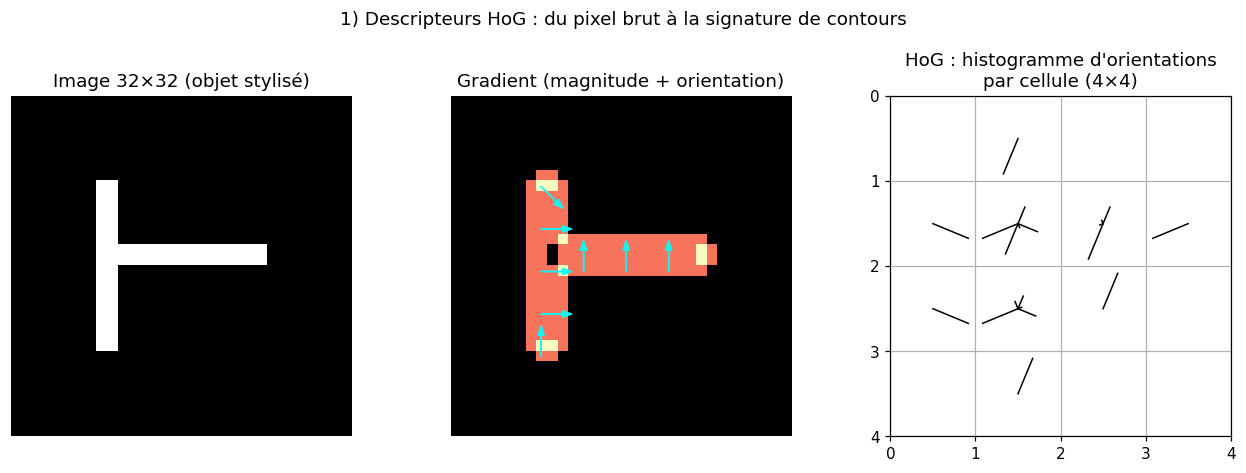

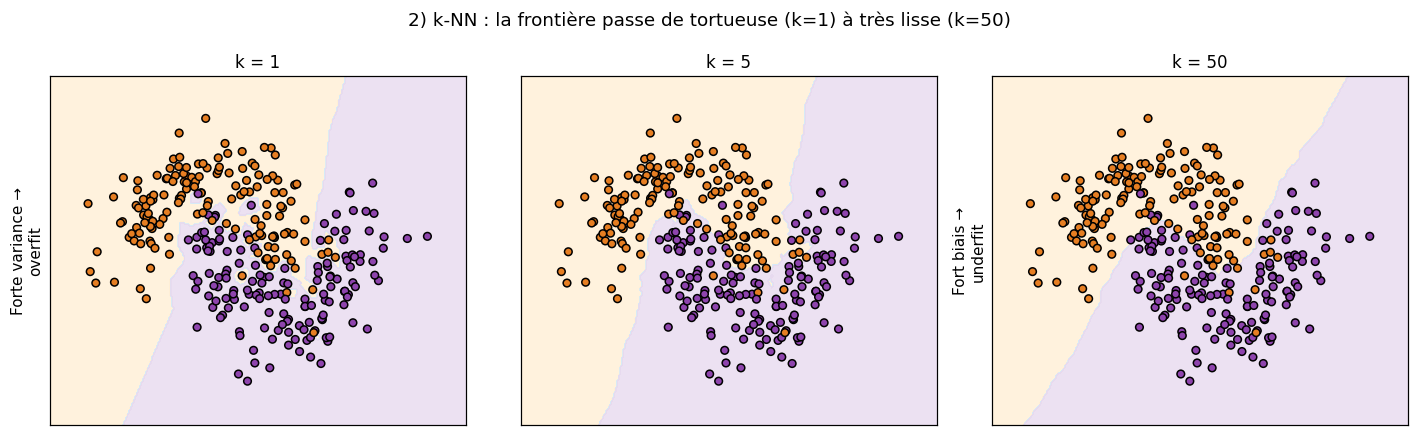

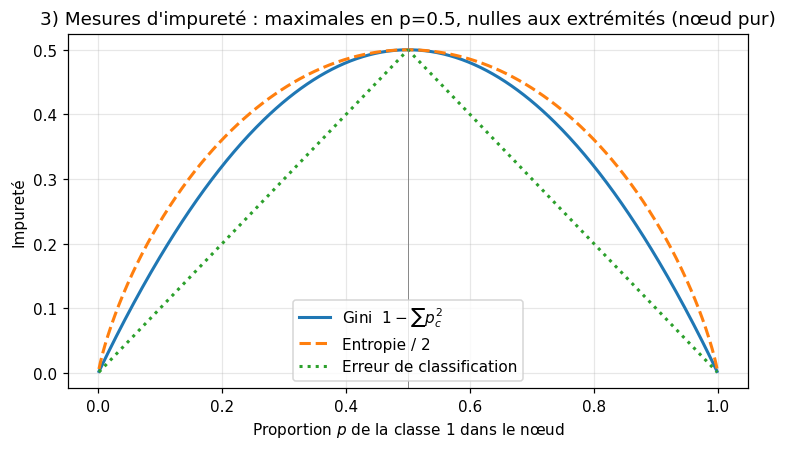

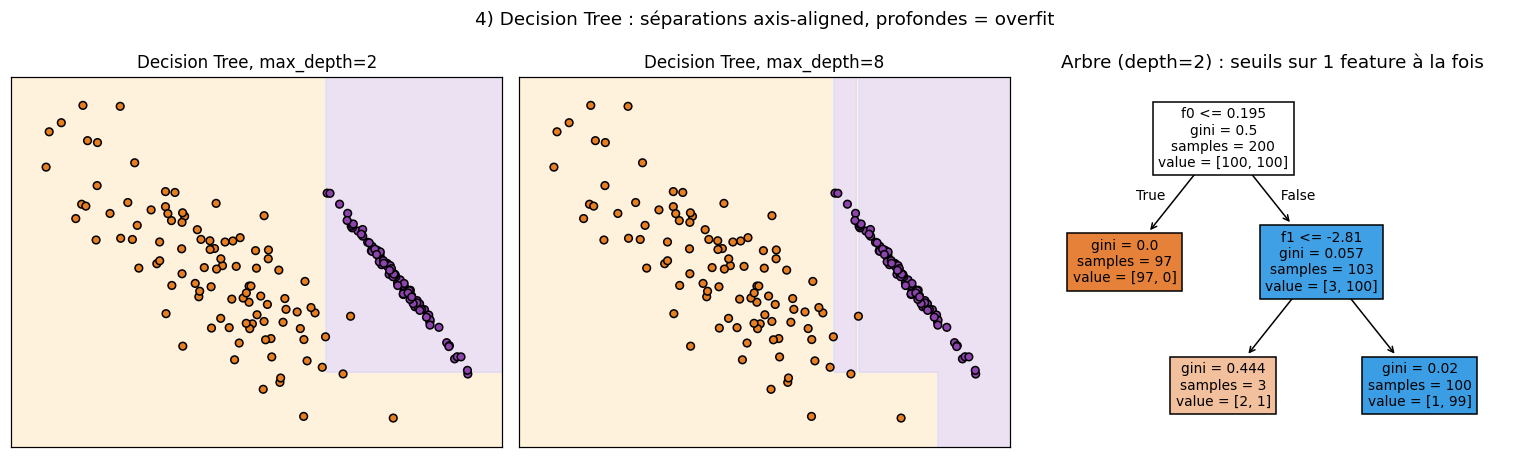

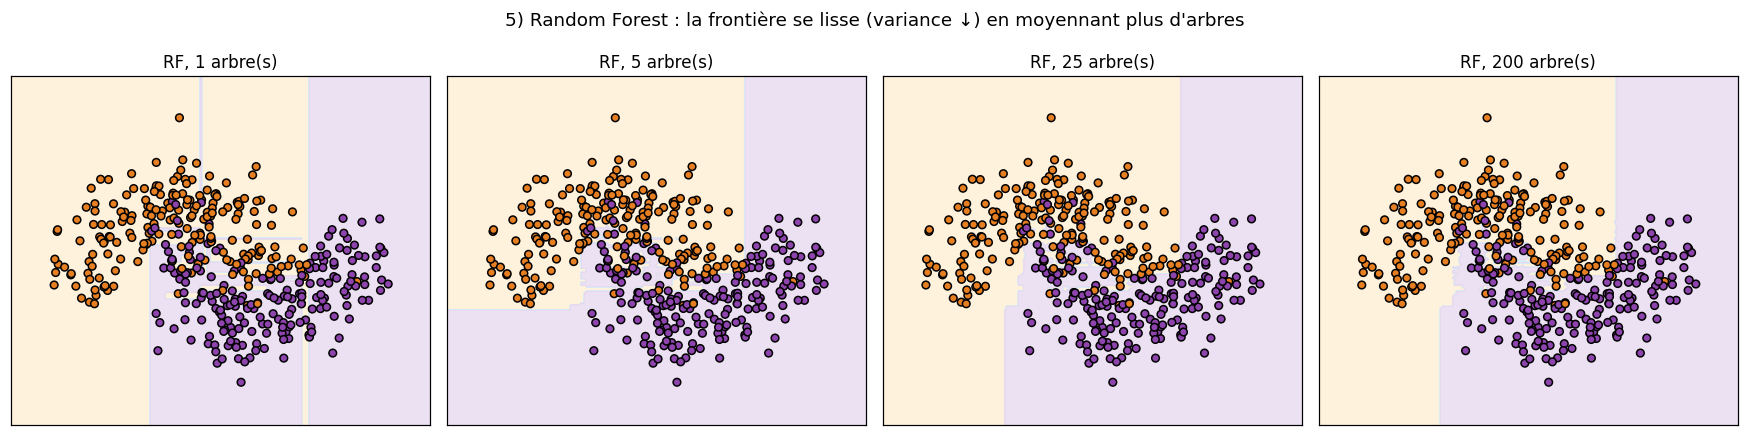

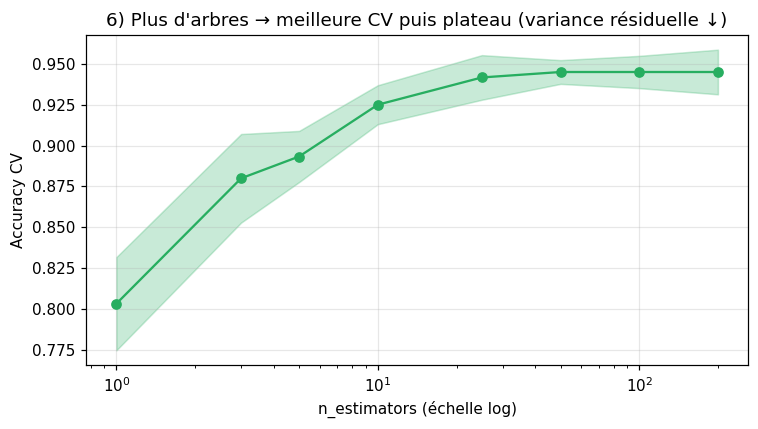

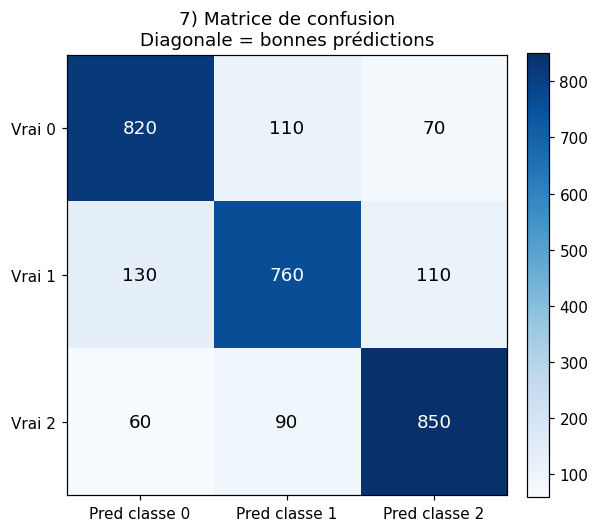

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons, make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

plt.rcParams["figure.dpi"] = 110
cmap_bg = ListedColormap(["#FFEFD5", "#D6EAF8", "#E8DAEF"])
cmap_pt = ListedColormap(["#E67E22", "#2980B9", "#8E44AD"])


def plot_decision(ax, clf, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_pt, edgecolors="k", s=25)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])


# =====================================================================
# 1) Descripteurs HoG : visualisation conceptuelle
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
np.random.seed(0)
img = np.zeros((32, 32))
img[8:24, 8:10] = 1.0           # vertical bar
img[14:16, 8:24] = 1.0          # horizontal bar (cross)
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Image 32×32 (objet stylisé)")
axes[0].axis("off")

# Gradient orientations
gy, gx = np.gradient(img)
mag = np.hypot(gx, gy)
ang = np.arctan2(gy, gx)
axes[1].imshow(mag, cmap="magma")
for i in range(0, 32, 4):
    for j in range(0, 32, 4):
        if mag[i, j] > 0.05:
            axes[1].arrow(j, i, 2 * np.cos(ang[i, j]), 2 * np.sin(ang[i, j]),
                          head_width=0.6, color="cyan", alpha=0.9)
axes[1].set_title("Gradient (magnitude + orientation)")
axes[1].axis("off")

# HoG histograms per cell (4×4 cells, 8 bins)
n_cells, n_bins = 4, 8
cell = 32 // n_cells
hog_grid = np.zeros((n_cells, n_cells, n_bins))
for ci in range(n_cells):
    for cj in range(n_cells):
        a = ang[ci*cell:(ci+1)*cell, cj*cell:(cj+1)*cell].ravel()
        m = mag[ci*cell:(ci+1)*cell, cj*cell:(cj+1)*cell].ravel()
        hist, _ = np.histogram(a, bins=n_bins, range=(-np.pi, np.pi), weights=m)
        hog_grid[ci, cj] = hist
ax = axes[2]
ax.set_xlim(0, n_cells); ax.set_ylim(0, n_cells)
ax.invert_yaxis()
for ci in range(n_cells):
    for cj in range(n_cells):
        h = hog_grid[ci, cj]
        if h.max() > 0:
            h = h / h.max()
        for b in range(n_bins):
            theta = -np.pi + (b + 0.5) * 2 * np.pi / n_bins
            ax.plot([cj + 0.5, cj + 0.5 + 0.45 * h[b] * np.cos(theta)],
                    [ci + 0.5, ci + 0.5 + 0.45 * h[b] * np.sin(theta)],
                    color="black", lw=1)
ax.set_xticks(range(n_cells + 1)); ax.set_yticks(range(n_cells + 1))
ax.grid(True); ax.set_title("HoG : histogramme d'orientations\npar cellule (4×4)")
ax.set_aspect("equal")
plt.suptitle("1) Descripteurs HoG : du pixel brut à la signature de contours", y=1.02)
plt.tight_layout(); plt.show()


# =====================================================================
# 2) k-NN : compromis biais–variance via la frontière de décision
# =====================================================================
X, y = make_moons(n_samples=300, noise=0.30, random_state=0)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, k in zip(axes, [1, 5, 50]):
    clf = KNeighborsClassifier(n_neighbors=k).fit(X, y)
    plot_decision(ax, clf, X, y, f"k = {k}")
axes[0].set_ylabel("Forte variance →\noverfit")
axes[2].set_ylabel("Fort biais →\nunderfit")
plt.suptitle("2) k-NN : la frontière passe de tortueuse (k=1) à très lisse (k=50)")
plt.tight_layout(); plt.show()


# =====================================================================
# 3) Critère de Gini (et entropie) en fonction de la pureté
# =====================================================================
p = np.linspace(1e-3, 1 - 1e-3, 500)
gini = 1 - p**2 - (1 - p)**2
entropy = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
mis = 1 - np.maximum(p, 1 - p)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(p, gini, label="Gini  $1-\\sum p_c^2$", lw=2)
ax.plot(p, entropy / 2, label="Entropie / 2", lw=2, ls="--")
ax.plot(p, mis, label="Erreur de classification", lw=2, ls=":")
ax.axvline(0.5, color="grey", lw=0.6)
ax.set_xlabel("Proportion $p$ de la classe 1 dans le nœud")
ax.set_ylabel("Impureté")
ax.set_title("3) Mesures d'impureté : maximales en p=0.5, nulles aux extrémités (nœud pur)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


# =====================================================================
# 4) Arbre de décision : frontières "axis-aligned" + visualisation arbre
# =====================================================================
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1,
                           class_sep=1.2, random_state=4)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, depth in zip(axes[:2], [2, 8]):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(X, y)
    plot_decision(ax, clf, X, y, f"Decision Tree, max_depth={depth}")
plot_tree(DecisionTreeClassifier(max_depth=2, random_state=0).fit(X, y),
          ax=axes[2], filled=True, feature_names=["f0", "f1"])
axes[2].set_title("Arbre (depth=2) : seuils sur 1 feature à la fois")
plt.suptitle("4) Decision Tree : séparations axis-aligned, profondes = overfit")
plt.tight_layout(); plt.show()


# =====================================================================
# 5) Random Forest : réduction de variance avec n_estimators
# =====================================================================
X, y = make_moons(n_samples=400, noise=0.30, random_state=1)
ks = [1, 5, 25, 200]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, n in zip(axes, ks):
    clf = RandomForestClassifier(n_estimators=n, max_depth=None,
                                 random_state=0).fit(X, y)
    plot_decision(ax, clf, X, y, f"RF, {n} arbre(s)")
plt.suptitle("5) Random Forest : la frontière se lisse (variance ↓) en moyennant plus d'arbres")
plt.tight_layout(); plt.show()


# =====================================================================
# 6) Effet de n_estimators sur l'accuracy CV (variance ↓ → accuracy ↑)
# =====================================================================
X, y = make_classification(n_samples=600, n_features=20, n_informative=8,
                           n_redundant=2, random_state=0)
ns = [1, 3, 5, 10, 25, 50, 100, 200]
means, stds = [], []
for n in ns:
    sc = cross_val_score(RandomForestClassifier(n_estimators=n, random_state=0),
                         X, y, cv=4, scoring="accuracy")
    means.append(sc.mean()); stds.append(sc.std())
means, stds = np.array(means), np.array(stds)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ns, means, "-o", color="#27AE60")
ax.fill_between(ns, means - stds, means + stds, alpha=0.25, color="#27AE60")
ax.set_xscale("log"); ax.set_xlabel("n_estimators (échelle log)")
ax.set_ylabel("Accuracy CV")
ax.set_title("6) Plus d'arbres → meilleure CV puis plateau (variance résiduelle ↓)")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


# =====================================================================
# 7) Matrice de confusion : structure et lecture
# =====================================================================
fig, ax = plt.subplots(figsize=(5.5, 5))
cm = np.array([[820, 110, 70], [130, 760, 110], [60, 90, 850]])
im = ax.imshow(cm, cmap="Blues")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > 500 else "black", fontsize=12)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(["Pred classe 0", "Pred classe 1", "Pred classe 2"])
ax.set_yticklabels(["Vrai 0", "Vrai 1", "Vrai 2"])
ax.set_title("7) Matrice de confusion\nDiagonale = bonnes prédictions")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()
